In [1]:
# import the stuff you need. Pytorch is already installed on Google colab
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchinfo import summary
from huggingface_hub import hf_hub_download
import jammy_flows
from scipy.stats import norm

import sys
sys.path.append('../')
from helper import *

c:\Users\hynda\OneDrive\Documents\Applied-Deep-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torchdiffeq not found - no support for continuous flows. Install *torchdiffeq* if support is desired!
Meander not installed... contours can not be calculated.
Healpy not installed... spherical contours can not be calculated.
package *astropy* not found -> if you want to use plotting functionality for adaptive grids, install *astropy*!
package *mhealpy* not found -> if you want to use plotting functionality for adaptive grids, install *mhealpy*!
Cannot use healpy functionality. Install healpy, if you need to do entropy scanning!


In [2]:
# Constants
DATA_PATH = "dataset"
BATCH_SIZE = 64
fp64_on_cpu = False

In [3]:
spectra = np.load(f"{DATA_PATH}/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{DATA_PATH}/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
label_units = ["K", "", ""]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]

# normalize the spectra
spectra = np.log(np.maximum(spectra, 0.2))

In [4]:
print("Spectra:", spectra.shape)
print("Labels:", labels.shape)

Spectra: (8914, 16384)
Labels: (8914, 3)


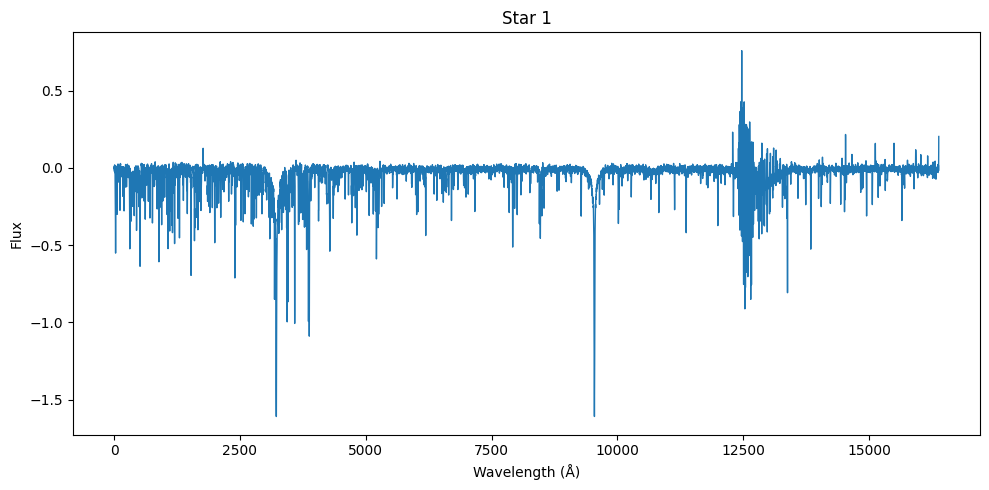

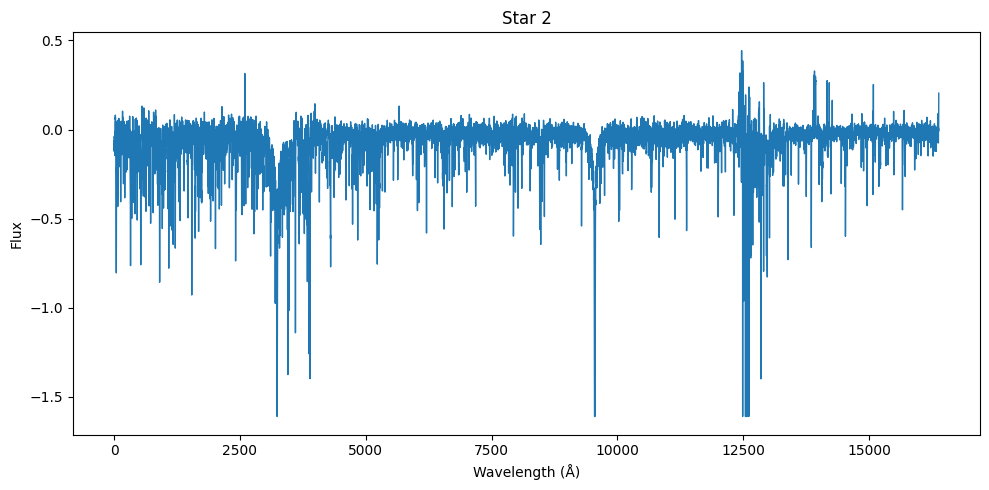

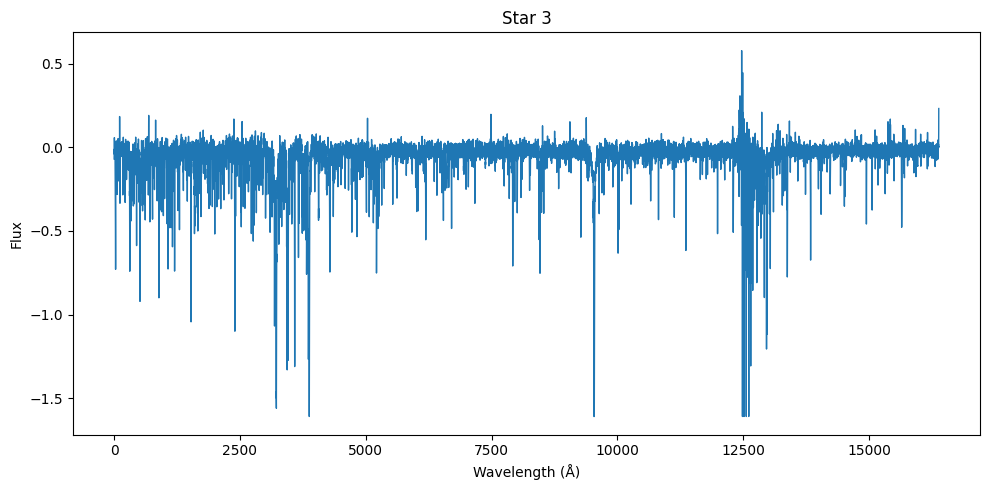

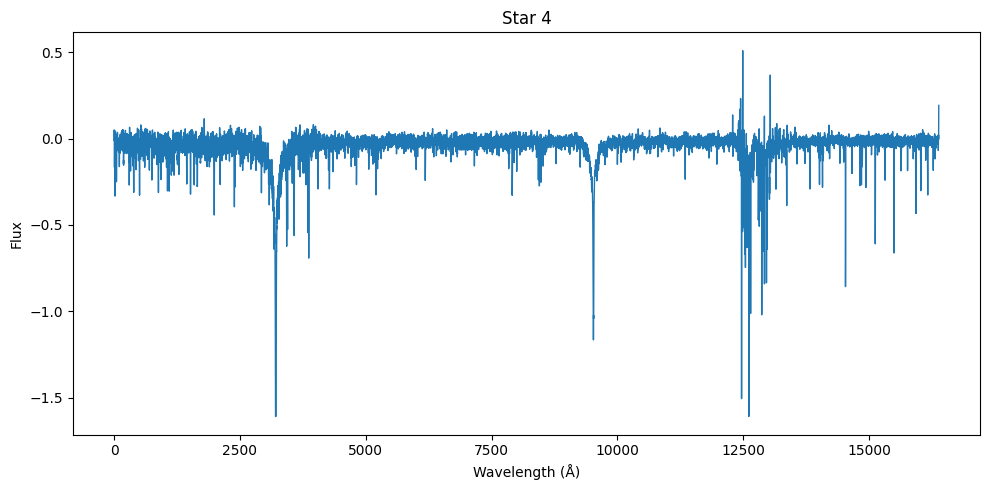

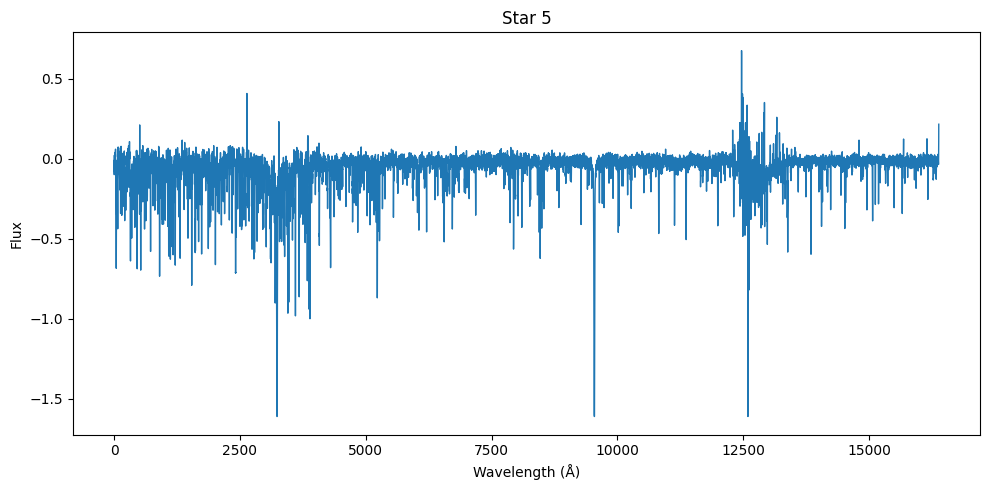

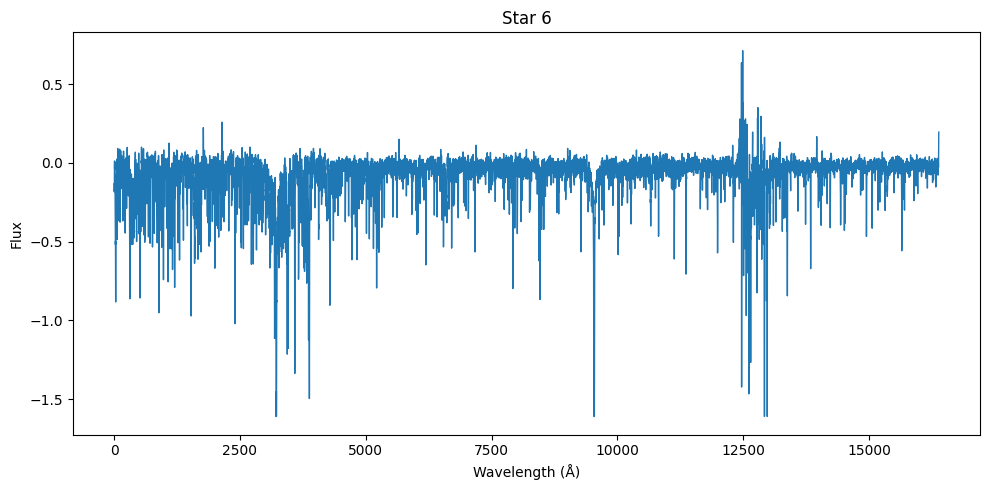

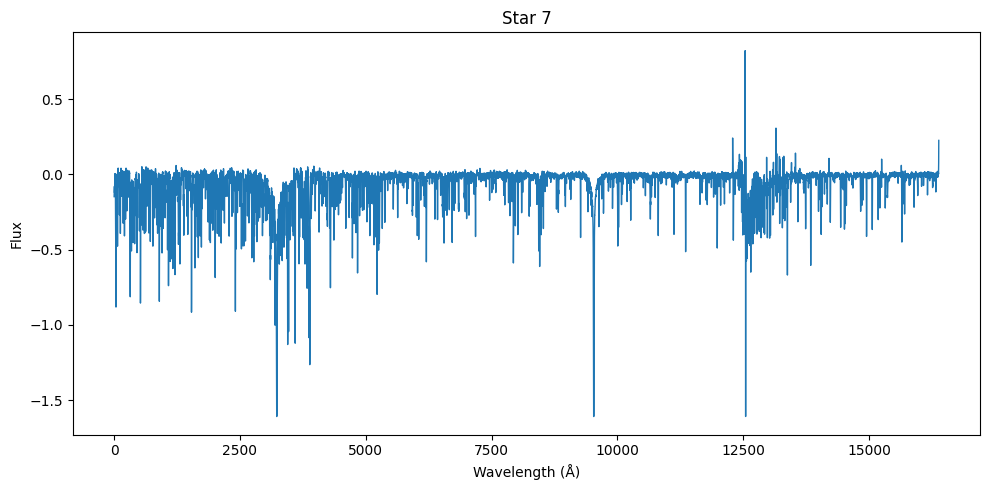

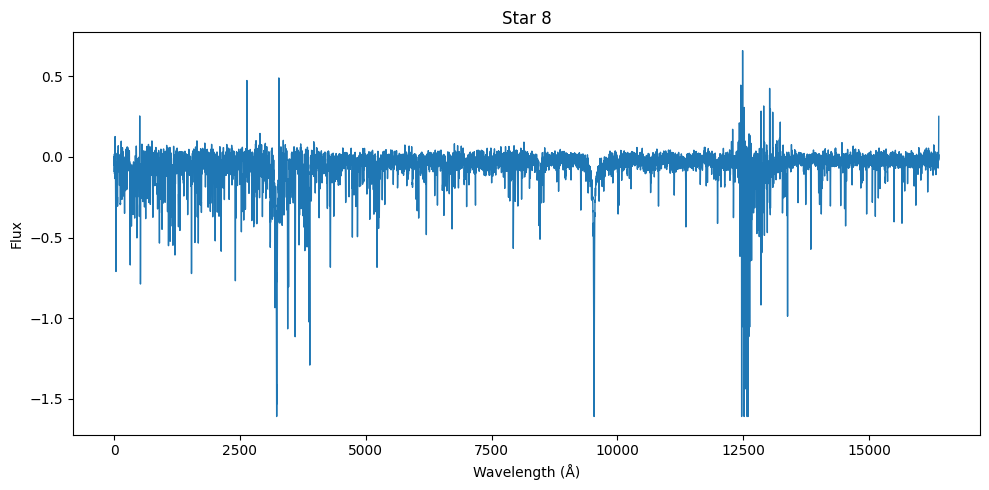

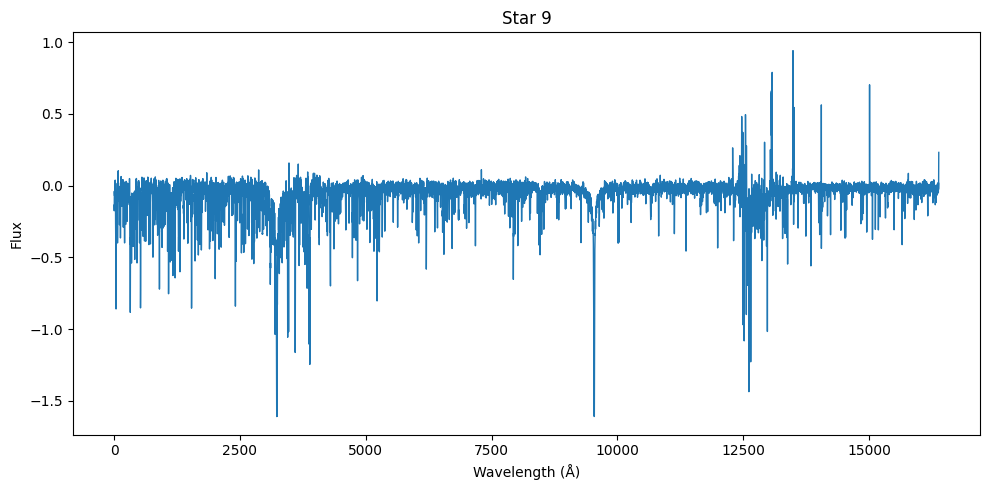

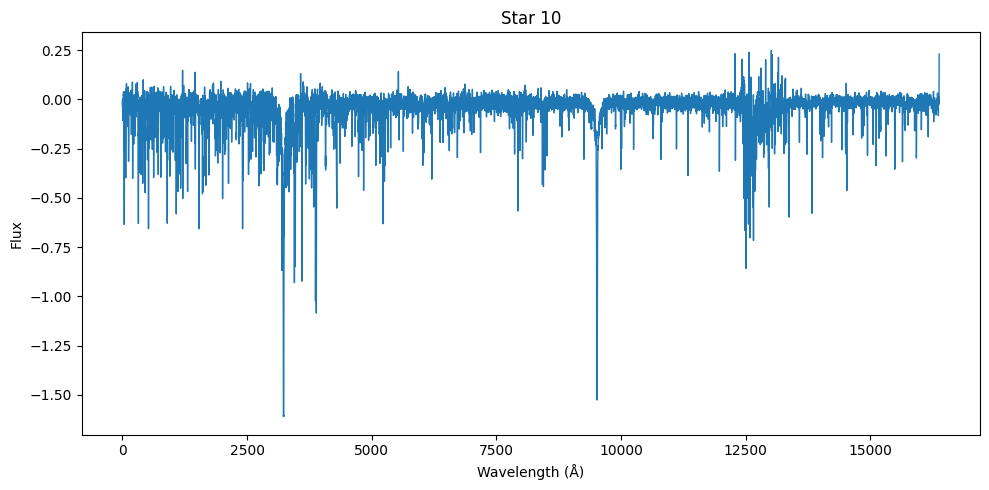

In [5]:
%matplotlib inline
# plot a few spectra
for i in range(10):
  fig, ax = plt.subplots(1, 1, figsize=(10, 5))
  ax.plot(spectra[i], lw=1)
  ax.set_title(f"Star {i+1}")
  plt.xlabel("Wavelength (Å)")
  plt.ylabel("Flux")
  plt.tight_layout()

In [6]:
# Splitting into train, val and test datasets

X_train, X_val, X_test, y_train, y_val, y_test = split_data(spectra, labels)

print(f"Shapes of train, test and val X : {X_train.shape}, {X_val.shape}, {X_test.shape}")
print(f"Shapes of train, test and val y : {y_train.shape}, {y_val.shape}, {y_test.shape}")

Shapes of train, test and val X : (6239, 16384), (1337, 16384), (1338, 16384)
Shapes of train, test and val y : (6239, 3), (1337, 3), (1338, 3)


In [7]:
y_train, y_val, y_test, mean, std = normalize_labels(y_train, y_val, y_test)

In [8]:
class SpectraEncoder(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dimension)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        return self.fc(x)

In [9]:
# NLL Loss function
def nf_loss(inputs, batch_labels, model):
    """
    Computes the loss for a normalizing flow model.

    Parameters
    ----------
    inputs : torch.Tensor
        The input data to the model.
    batch_labels : torch.Tensor
        The labels corresponding to the input data.
    model : torch.nn.Module
        The normalizing flow model used for evaluation.
    Returns
    -------
    torch.Tensor
        The computed loss value.
    """
    log_pdfs = model.log_pdf_evaluation(batch_labels, inputs) # get the probability of the labels given the input data
    loss = -log_pdfs.mean() # take the negative mean of the log probabilities
    return loss

In [10]:
class CombinedModel(nn.Module):
    """
    A combined model that integrates a normalizing flow with a CNN encoder.
    """

    def __init__(self, encoder, nf_type="diagonal_gaussian"):
        """
        Initializes the normalizing flow model.

        Parameters
        ----------
        encoder : callable
            A function or callable object that returns an encoder model. The encoder model
            should take the number of flow parameters as input and output the latent dimension.
        nf_type : str, optional
            The type of normalizing flow to use. Options are "diagonal_gaussian", "full_gaussian",
            and "full_flow". Default is "diagonal_gaussian".
        Raises
        ------
        Exception
            If an unknown `nf_type` is provided.
        Notes
        -----
        This method sets up a 3-dimensional probability density function (PDF) over Euclidean space (e3)
        using the specified normalizing flow type. The flow structure and options are configured based on
        the provided `nf_type`. The PDF is created using the `jammy_flows` library, and the number of flow
        parameters is determined and printed. The encoder is initialized with the number of flow parameters.
        """

        super().__init__()

        # we define a 3-d PDF over Euclidean spae (e3)
        # using recommended settings (https://github.com/thoglu/jammy_flows/issues/5 scroll down)
        opt_dict = {}
        opt_dict["t"] = {}
        if (nf_type == "diagonal_gaussian"):
            opt_dict["t"]["cov_type"] = "diagonal"
            flow_defs = "t"
        elif (nf_type == "full_gaussian"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "t"
        elif (nf_type == "full_flow"):
            opt_dict["t"]["cov_type"] = "full"
            flow_defs = "gggt"
        else:
            raise Exception("Unknown nf type ", nf_type)

        opt_dict["g"] = dict()
        opt_dict["g"]["fit_normalization"] = 1
        opt_dict["g"]["upper_bound_for_widths"] = 1.0
        opt_dict["g"]["lower_bound_for_widths"] = 0.01

        self.nf_type = nf_type

        # 3d PDF (e3) with ggggt flow structure. Four Gaussianation-flow (https://arxiv.org/abs/2003.01941) layers ("g") and an affine flow ("t")
        self.pdf = jammy_flows.pdf("e3", flow_defs, options_overwrite=opt_dict,
                                   amortize_everything=True, amortization_mlp_use_custom_mode=True)

        # get the number of flow parameters
        num_flow_parameters = self.pdf.total_number_amortizable_params

        print("The normalizing flow has ", num_flow_parameters, " parameters...")

        # latent dimension (output of the CNN encoder) is set to 128
        self.encoder = encoder(num_flow_parameters)

    def log_pdf_evaluation(self, target_labels, input_data):
        """
        Evaluate the log probability density function (PDF) for the given target labels and input data.

        The normalizing flow parameters are predicted by the encoder network based on the input data.
        Then, the log PDF is evaluated at the position of the label.

        Parameters:
        -----------
        target_labels : torch.Tensor
            The target labels for which the log PDF is to be evaluated.
        input_data : torch.Tensor
            The input data to be encoded and used for evaluating the log PDF.
        Returns:
        --------
        log_pdf : torch.Tensor
            The evaluated log PDF for the given target labels and input data.
        """
        latent_intermediate = self.encoder(input_data)

        if self.nf_type == "full_flow":
            # Stay on GPU, just cast to float64
            latent_intermediate = latent_intermediate.to(torch.float64)
            target_labels = target_labels.to(torch.float64)

        log_pdf, _, _ = self.pdf(target_labels, amortization_parameters=latent_intermediate)
        return log_pdf

    def sample(self, flow_params, samplesize_per_batchitem=1000):
        """
        Sample new points from the PDF given input data.

        Parameters
        ----------
        flow_params : tensor
            Parameters for the normalizing flow, must be of shape (B, L) where B is the batch size and L is the latent dimension.
        samplesize_per_batchitem : int, optional
            Number of samples to draw per batch item. Defaults to 1000.

        Returns
        -------
        tensor
            A tensor of shape (B, S, D) where B is the batch dimension, S is the number of samples, 
            and D is the dimension of the target space for the samples.
        """
        # for full flow we need to convert to double precision for the normalizing flow
        # for numerical stability
        original_device = flow_params.device  # remember original device
    
        if self.nf_type == "full_flow":
            flow_params = flow_params.to(torch.float64)  # stay on GPU

        batch_size = flow_params.shape[0]
        repeated_samples, _, _, _ = self.pdf.sample(
            amortization_parameters=flow_params.repeat_interleave(samplesize_per_batchitem, dim=0),
            allow_gradients=False
        )

        reshaped_samples = repeated_samples[:, None, :].view(batch_size, samplesize_per_batchitem, -1)
        
        # cast back to float32 and original device
        return reshaped_samples.to(torch.float32).to(original_device)

    def forward(self, input_data, samplesize_per_batchitem=1000):
        """
        Perform a forward pass through the model, predicting the mean and standard deviation of the samples.

        Normalizing flows do not directly predict the target labels. Instead, they predict the parameters of the flow that
        transforms the base distribution to the target distribution. Often, we still want to predict the target labels.
        Then, we can sample from the distribution and form the mean of the samples and their standard deviations.
        This is what this function does.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor.
        Returns
        -------
        torch.Tensor
            A tensor of size (B, D*2) where the first half (size D) are the means, 
            the second half (another D) are the standard deviations.
        """
        flow_params=self.encoder(input_data)
        samples=self.sample(flow_params, samplesize_per_batchitem=samplesize_per_batchitem)

        # form mean along dim 1 (samples)
        means=samples.mean(dim=1)
        # form std along dim 1 (samples)
        std_deviations=samples.std(dim=1)

        # return means and std deviations as a concatenated tensor along dim 1
        return torch.cat([means, std_deviations], dim=1)

    def visualize_pdf(self, input_data, filename, samplesize=1000, batch_index=0, truth=None):
        """
        Visualizes the probability density function (PDF) of the given input data using a normalizing flow model.

        The function generates samples from the normalizing flow (using the sample() function) 
        and plots the histogram of the samples together with a Gaussian approximation.

        Parameters
        ----------
        input_data : torch.Tensor
            The input data tensor from which to pick one batch item for visualization.
        filename : str
            The filename where the resulting plot will be saved.
        samplesize : int, optional
            The number of samples to generate for the PDF visualization (default is 10000).
        batch_index : int, optional
            The index of the batch item to visualize (default is 0).
        truth : torch.Tensor, optional
            The true values of the labels, used for comparison in the plot (default is None).

        Returns
        -------
        None
        """
        # pick out one input from batch
        input_bitem = input_data[batch_index:batch_index+1]

        # get the flow parameters (by passing the input data through the CNN encoder network)
        flow_params = self.encoder(input_bitem)

        # sample from the normalizing flow (i.e. samples are drawn from the base distribution and transformed by the flow
        # using the change-of-variable formula)
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize)
        # the rest of the code is just plotting.

        # we only have 1 batch item
        samples = samples.squeeze(0)

        # plot three 1-dimensional distributions together with normal approximation,
        # so we calculate the mean and std of the samples
        mean = samples.mean(dim=0).cpu().numpy()
        std = samples.std(dim=0).cpu().numpy()
        samples = samples.cpu().numpy()

        fig, axdict = plt.subplots(3, 1)
        for dim_ind in range(3):
            # plot the histogram of the samples
            axdict[dim_ind].hist(samples[:, dim_ind], color="k", density=True,
                                 bins=50, alpha=0.5, label="density based on samples")

            # plot the Gaussian approximation
            min_sample = samples[:, dim_ind].min()
            max_sample = samples[:, dim_ind].max()
            xvals = np.linspace(min_sample, max_sample, 1000)
            yvals = norm.pdf(xvals, loc=mean[dim_ind], scale=std[dim_ind])
            axdict[dim_ind].plot(xvals, yvals, color="green",
                                 label="Gaussian approximation")

            # plot the true value if it is given
            if (truth is not None):
                true_value = truth[dim_ind].cpu().item()
                axdict[dim_ind].axvline(
                    true_value, color="red", label="true value")

            # plot the legend only for the first panel
            if (dim_ind == 0):
                axdict[dim_ind].legend()

        plt.savefig(filename)
        plt.close(fig)

In [11]:
train_loader, val_loader, test_loader = load_dataset(
    X_train, y_train, X_val, y_val, X_test, y_test, batch_size=32
)

device = torch.device("cuda" if torch.cuda.is_available() 
                       else "mps" if torch.backends.mps.is_available() 
                       else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [12]:
def plot_uncertainty_distribution(preds, label_names=["T_eff", "log_g", "Fe/H"], label_units=None):
    
    n = len(label_names)

    if label_units is None:
        label_units = [""] * n

    stds = preds

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    if n == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        unit = label_units[i]
        unit_str = f" (in {unit})" if unit and unit.lower() != "unitless" else ""

        ax.hist(stds[:, i], bins=50, color="steelblue", alpha=0.7)
        ax.set_title(f"{label_names[i]} uncertainty")
        ax.set_xlabel(f"Predicted std{unit_str}")
        ax.set_ylabel("Count")

        median_val = np.median(stds[:, i])
        ax.axvline(
            median_val,
            color="red",
            linestyle="--",
            label=f"Median: {median_val:.3f}"
        )
        ax.legend()

    plt.suptitle("Predicted Uncertainty Distributions", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Summary stats
    for i, name in enumerate(label_names):
        print(
            f"{name}: median std = {np.median(stds[:, i]):.4f}, "
            f"mean std = {np.mean(stds[:, i]):.4f}, "
            f"min = {np.min(stds[:, i]):.4f}, "
            f"max = {np.max(stds[:, i]):.4f}"
        )

In [13]:
config = {
    "epochs": 300,
    "lr": 1e-3,
    "optimizer": "adam",
    "weight_decay": 1e-5,
    "loss_fn": "nf_loss",          
    "cosine": {"T_max": 300},      # cosine LR decay
    "early_stop": {"patience": 15},
    "save_path": "logs/diag_gaussian.csv",
    "model_name": "diag_gaussian",
}


In [14]:
# --- Model 1: Diagonal Gaussian ---
model_diag = CombinedModel(SpectraEncoder, nf_type="diagonal_gaussian").to(device)

sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) options overwrite  cov_type  with  diagonal
The normalizing flow has  6  parameters...


In [15]:
# train_losses, val_losses = train_model(model_diag, train_loader, val_loader, config, device)

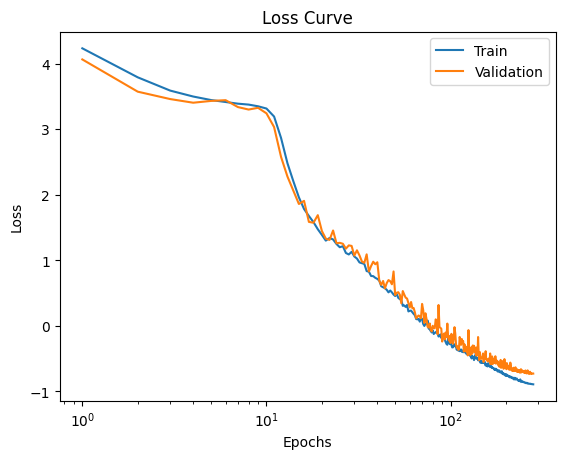

In [16]:
plot_loss("logs/diag_gaussian.csv", log_scale= True)

In [17]:
preds_diag, y_true = evaluate_model(model_diag, test_loader, device, config, precomputed=True)

Loaded precomputed weights from best_model_diag_gaussian.pth
Average test loss: -0.3545


In [18]:
def evaluate_uncertainty_quality(preds, y_true, label_names, savefig=True):

    if savefig:
        os.makedirs("plots", exist_ok=True)

    n_labels = len(label_names)

    means = preds[:, :n_labels]
    stds  = preds[:, n_labels:]

    if np.any(stds <= 0):
        print("WARNING: Some predicted stds are <= 0. Check your model output.")

    pulls = (means - y_true) / stds
    results = {}

    # ---- CREATE ONE FIGURE ----
    fig, axes = plt.subplots(1, n_labels, figsize=(5*n_labels, 4))

    if n_labels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        label = label_names[i]
        p = pulls[:, i]

        mean_pull = np.mean(p)
        std_pull  = np.std(p)

        coverage_68 = np.mean(np.abs(p) < 1.0)
        coverage_95 = np.mean(np.abs(p) < 2.0)

        results[label] = {
            "mean_pull":   mean_pull,
            "std_pull":    std_pull,
            "coverage_68": coverage_68,
            "coverage_95": coverage_95,
        }

        # ---- Console output (unchanged) ----
        print(f"\n{'='*40}")
        print(f"  {label}")
        print(f"{'='*40}")
        print(f"  Pull mean : {mean_pull:+.3f}  (ideal: 0.000)")
        print(f"  Pull std  : {std_pull:.3f}   (ideal: 1.000)")
        print(f"  Coverage 1 std: {coverage_68*100:.1f}%  (ideal: 68.3%)")
        print(f"  Coverage 2 std: {coverage_95*100:.1f}%  (ideal: 95.4%)")

        # ---- Plot on subplot ----
        counts, bins, _ = ax.hist(
            p,
            bins="auto",
            alpha=0.6,
            color="steelblue",
            label="Pulls"
        )

        x = np.linspace(bins[0], bins[-1], 300)
        bin_width = bins[1] - bins[0]

        # Ideal Gaussian
        ideal = norm.pdf(x, 0, 1) * len(p) * bin_width
        ax.plot(x, ideal, "--", linewidth=1.5, color="green", label="Ideal N(0,1)")

        # Fitted Gaussian
        fitted = norm.pdf(x, mean_pull, std_pull) * len(p) * bin_width
        ax.plot(
            x,
            fitted,
            "r-",
            linewidth=1.5,
            label=f"Fit: mean={mean_pull:+.2f}, std={std_pull:.2f}"
        )

        ax.set_title(label)
        ax.set_xlabel("Pulls")
        ax.set_ylabel("Counts")
        ax.legend(fontsize=8)

    plt.suptitle("Pull Distribution", fontsize = 14)
    plt.tight_layout()

    if savefig:
        plt.savefig("plots/uncertainty_quality.png", dpi=300)

    plt.show()

    return results


  T_eff
  Pull mean : -0.050  (ideal: 0.000)
  Pull std  : 1.066   (ideal: 1.000)
  Coverage 1 std: 66.1%  (ideal: 68.3%)
  Coverage 2 std: 94.6%  (ideal: 95.4%)

  log_g
  Pull mean : +0.014  (ideal: 0.000)
  Pull std  : 1.081   (ideal: 1.000)
  Coverage 1 std: 71.0%  (ideal: 68.3%)
  Coverage 2 std: 94.5%  (ideal: 95.4%)

  Fe/H
  Pull mean : -0.023  (ideal: 0.000)
  Pull std  : 1.017   (ideal: 1.000)
  Coverage 1 std: 70.3%  (ideal: 68.3%)
  Coverage 2 std: 95.2%  (ideal: 95.4%)


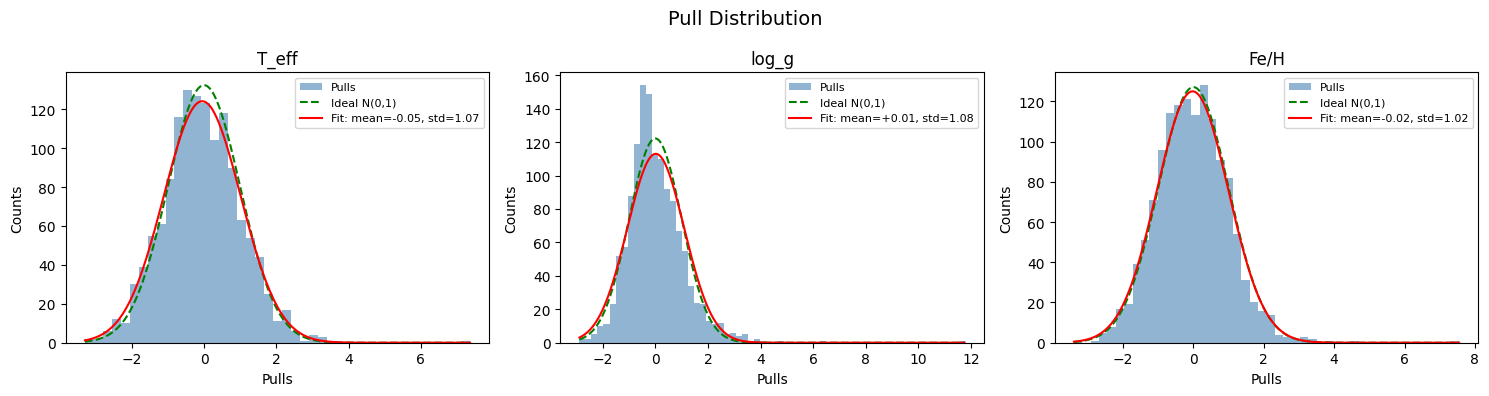

In [19]:
results = evaluate_uncertainty_quality(preds_diag, y_true, ["T_eff", "log_g", "Fe/H"])

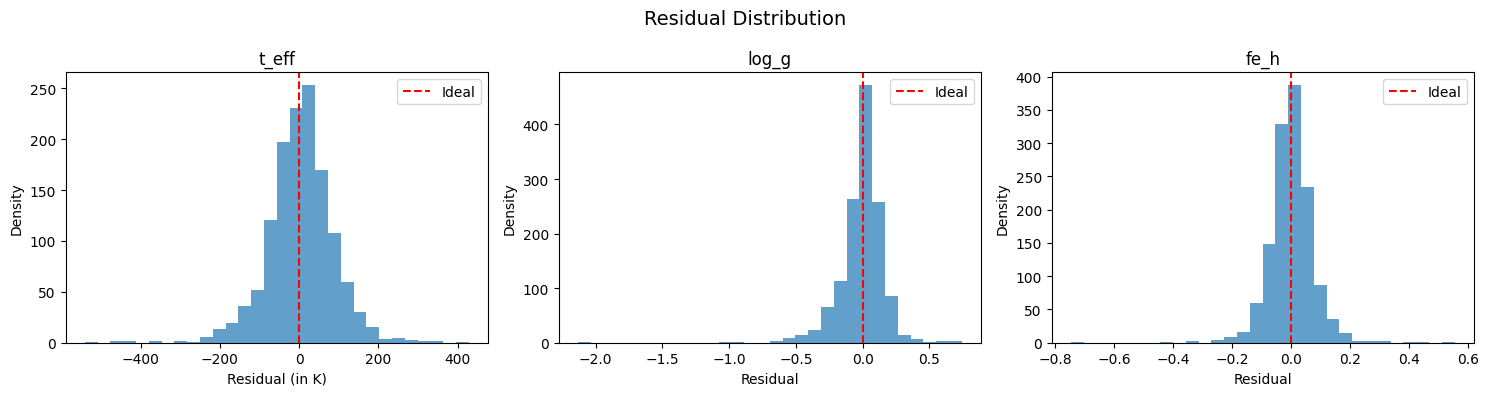

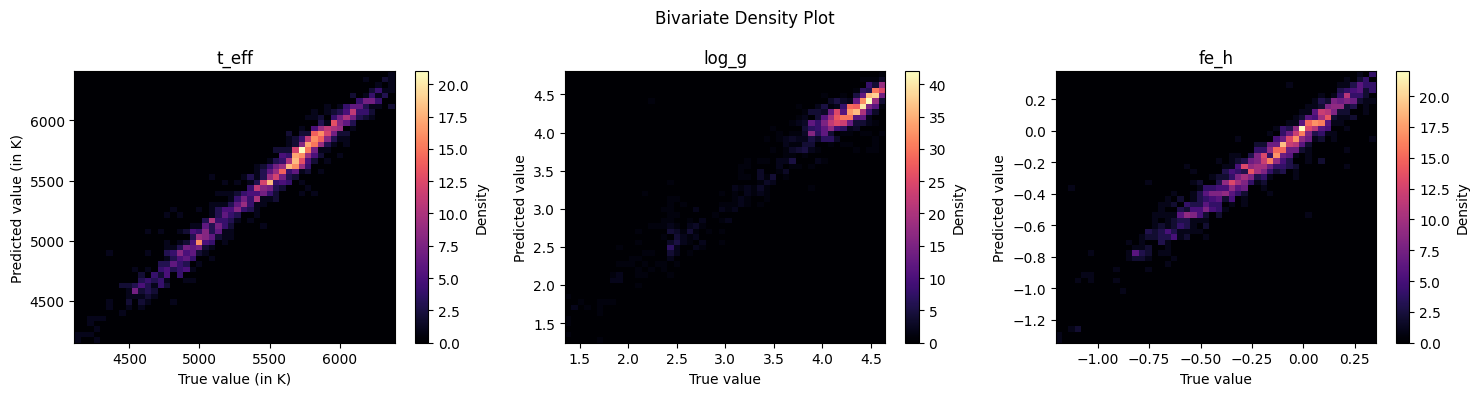

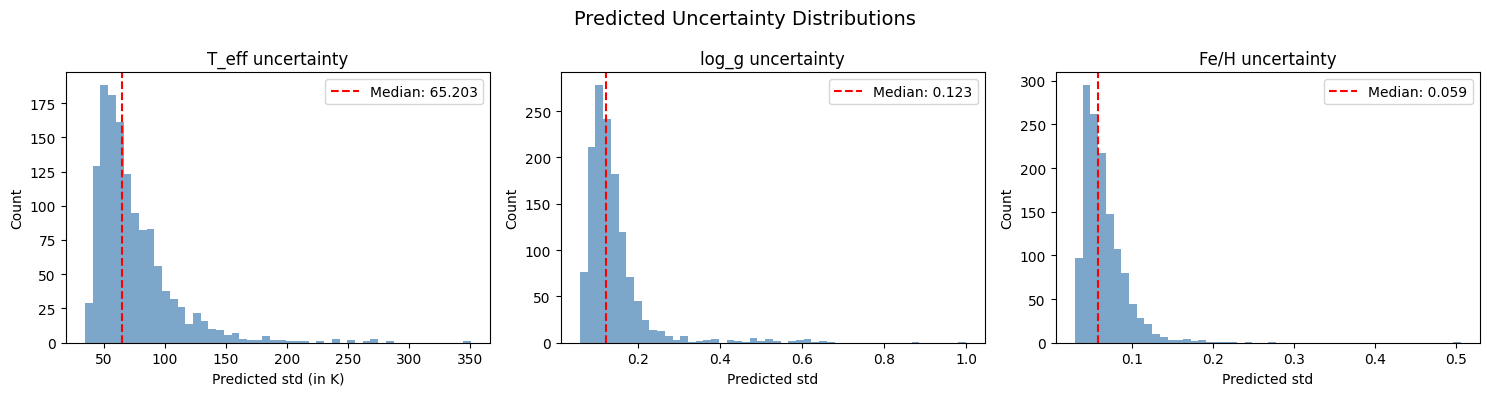

T_eff: median std = 65.2034, mean std = 74.5085, min = 34.4210, max = 350.8744
log_g: median std = 0.1232, mean std = 0.1428, min = 0.0594, max = 0.9987
Fe/H: median std = 0.0587, mean std = 0.0654, min = 0.0297, max = 0.5055


In [20]:
y_true_denorm = denormalize_labels(y_true, mean, std)
means_diag_denorm = denormalize_labels(preds_diag[:, :3], mean, std)
stds_diag_denorm = preds_diag[:, 3:] * std

plot_residuals(y_true_denorm, means_diag_denorm, labelNames, label_units=label_units)
plot_heatmap(y_true_denorm, means_diag_denorm, labelNames, label_units=label_units)

plot_uncertainty_distribution(stds_diag_denorm, label_units=label_units)

In [21]:
# --- Model 2: Full Gaussian ---
config["save_path"]   = "logs/full_gaussian.csv"
config["model_name"]  = "full_gaussian"

In [22]:
# --- Model 2: Full Gaussian ---
model_full = CombinedModel(SpectraEncoder, nf_type="full_gaussian").to(device)

sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) options overwrite  cov_type  with  full
The normalizing flow has  9  parameters...


In [23]:
# train_losses, val_losses = train_model(model_full, train_loader, val_loader, config, device)


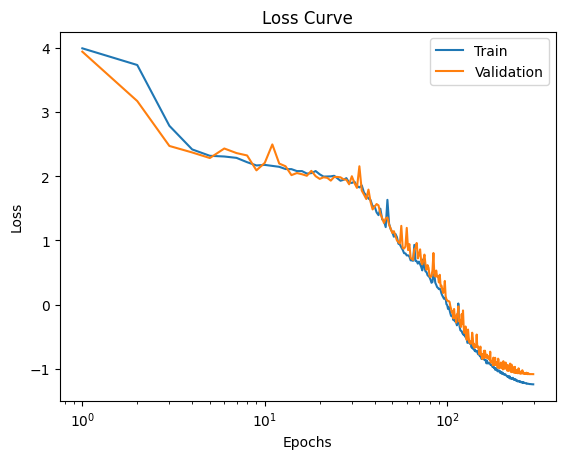

In [24]:
plot_loss("logs/full_gaussian.csv", log_scale= True)

Loaded precomputed weights from best_model_full_gaussian.pth
Average test loss: -0.5585

  T_eff
  Pull mean : -0.087  (ideal: 0.000)
  Pull std  : 1.034   (ideal: 1.000)
  Coverage 1 std: 67.2%  (ideal: 68.3%)
  Coverage 2 std: 94.4%  (ideal: 95.4%)

  log_g
  Pull mean : -0.039  (ideal: 0.000)
  Pull std  : 1.019   (ideal: 1.000)
  Coverage 1 std: 72.0%  (ideal: 68.3%)
  Coverage 2 std: 95.3%  (ideal: 95.4%)

  Fe/H
  Pull mean : -0.055  (ideal: 0.000)
  Pull std  : 1.012   (ideal: 1.000)
  Coverage 1 std: 68.6%  (ideal: 68.3%)
  Coverage 2 std: 95.1%  (ideal: 95.4%)


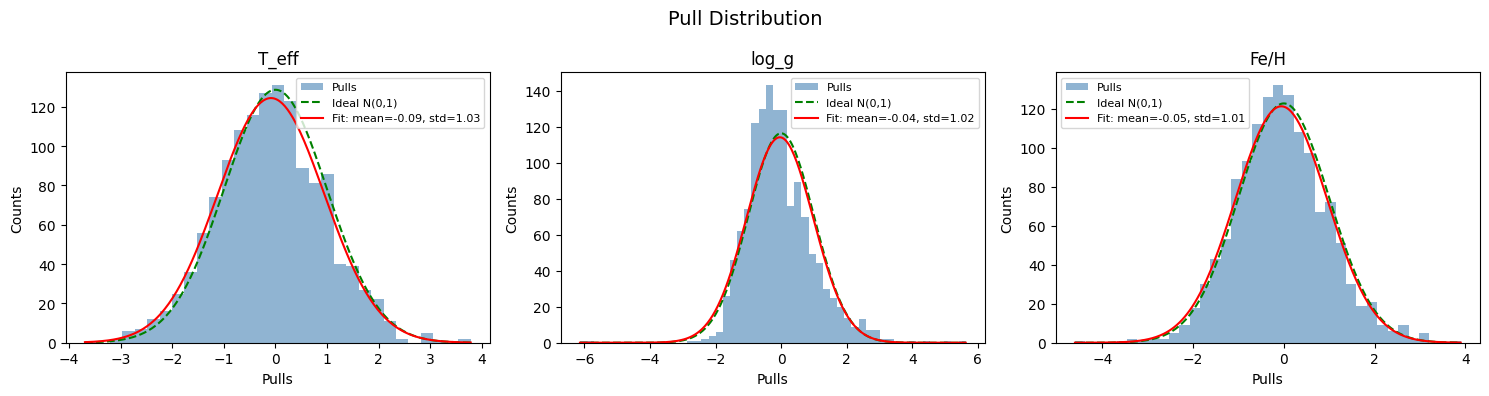

In [25]:
preds_full, y_true = evaluate_model(model_full, test_loader, device, config, precomputed=True)
results = evaluate_uncertainty_quality(preds_full, y_true, ["T_eff", "log_g", "Fe/H"])

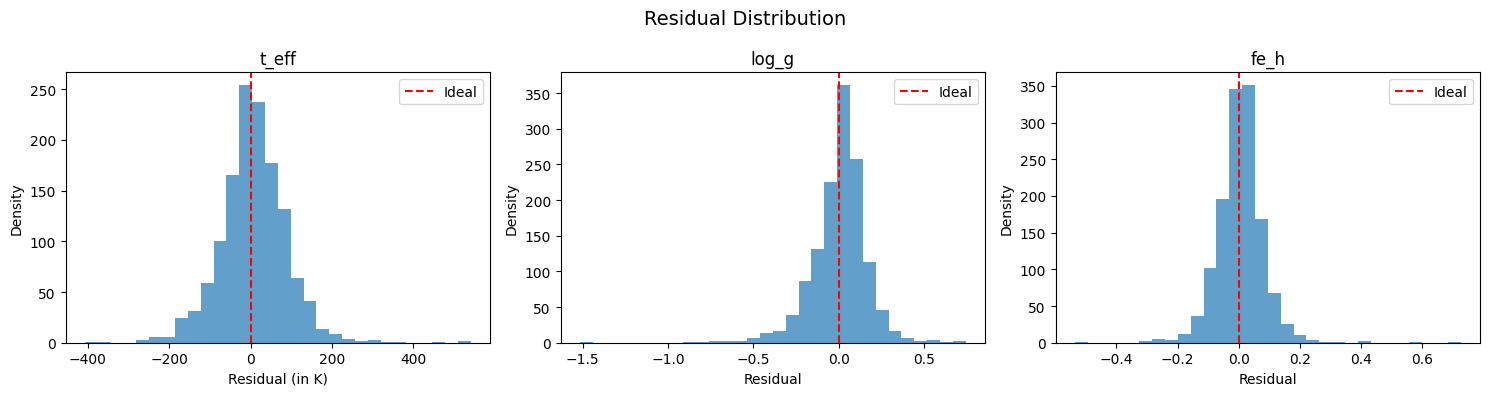

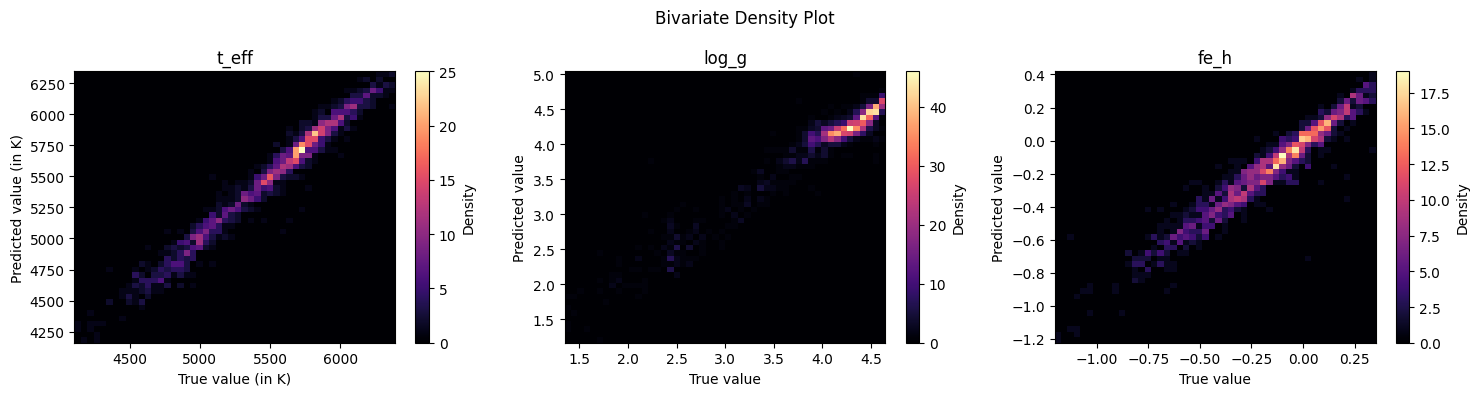

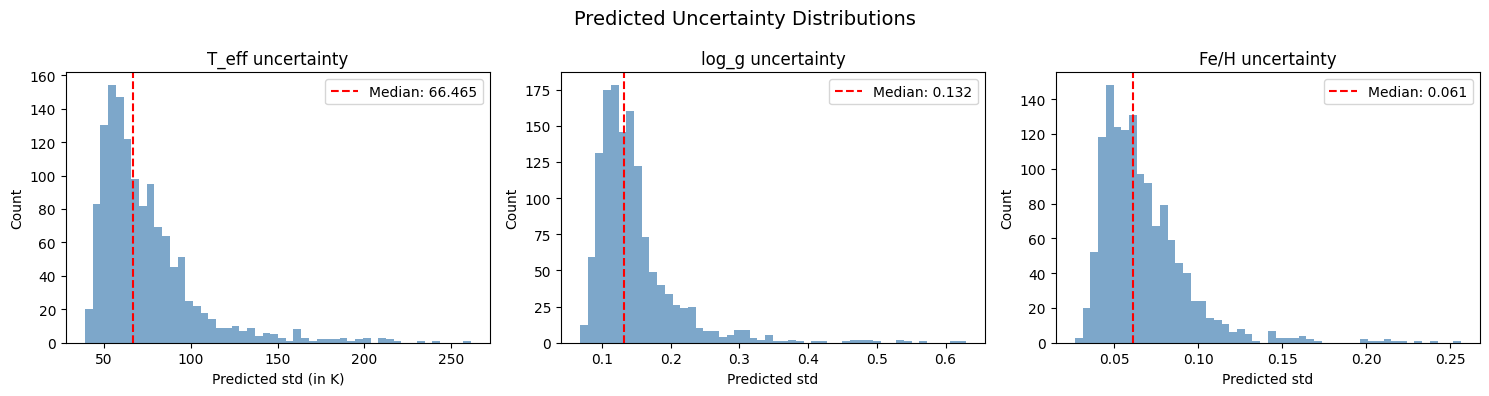

T_eff: median std = 66.4651, mean std = 74.1806, min = 39.0938, max = 261.3409
log_g: median std = 0.1322, mean std = 0.1474, min = 0.0679, max = 0.6293
Fe/H: median std = 0.0611, mean std = 0.0675, min = 0.0265, max = 0.2563


In [26]:
y_true_denorm = denormalize_labels(y_true, mean, std)
means_full_denorm = denormalize_labels(preds_full[:, :3], mean, std)
stds_full_denorm = preds_full[:, 3:] * std

plot_residuals(y_true_denorm, means_full_denorm, labelNames, label_units=label_units)
plot_heatmap(y_true_denorm, means_full_denorm, labelNames, label_units=label_units)

plot_uncertainty_distribution(stds_full_denorm, label_units=label_units)

In [27]:
class SpectraEncoderGGGT(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dimension)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = self.global_pool(x)
        x = x.squeeze(-1)
        return self.fc(x)

In [28]:
# --- Model 3: Full Flow (Gaussianization) ---
config["save_path"]   = "logs/full_flow.csv"
config["model_name"]  = "full_flow"
config["lr"] = 1e-4
config["early_stop"] = {"patience": 50}
config["epochs"] = 600
config["cosine"] = {"T_max": 600}

model_flow = CombinedModel(SpectraEncoderGGGT, nf_type="full_flow").to(device)


sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (0 - g) options overwrite  lower_bound_for_widths  with  0.01
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (1 - g) options overwrite  lower_bound_for_widths  with  0.01
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  fit_normalization  with  1
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  upper_bound_for_widths  with  1.0
sub-manifold (0 - e3 - gggt) and intra-manifold flow (2 - g) options overwrite  lower_bound_for_widths  wit

In [29]:

# train_losses, val_losses = train_model(model_flow, train_loader, val_loader, config, device)


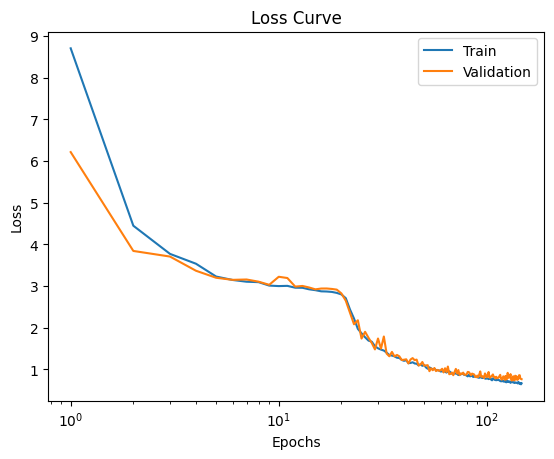

In [30]:
plot_loss("logs/full_flow.csv", log_scale=True)

In [31]:
preds_flow, y_true = evaluate_model(model_flow, test_loader, device, config, precomputed=True)
preds_flow.shape

Loaded precomputed weights from best_model_full_flow.pth
Average test loss: 0.3500


(1338, 6)


  t_eff
  Pull mean : -0.069  (ideal: 0.000)
  Pull std  : 0.956   (ideal: 1.000)
  Coverage 1 std: 68.1%  (ideal: 68.3%)
  Coverage 2 std: 97.2%  (ideal: 95.4%)

  log_g
  Pull mean : -0.106  (ideal: 0.000)
  Pull std  : 0.939   (ideal: 1.000)
  Coverage 1 std: 84.7%  (ideal: 68.3%)
  Coverage 2 std: 95.2%  (ideal: 95.4%)

  fe_h
  Pull mean : -0.091  (ideal: 0.000)
  Pull std  : 0.907   (ideal: 1.000)
  Coverage 1 std: 75.7%  (ideal: 68.3%)
  Coverage 2 std: 96.3%  (ideal: 95.4%)


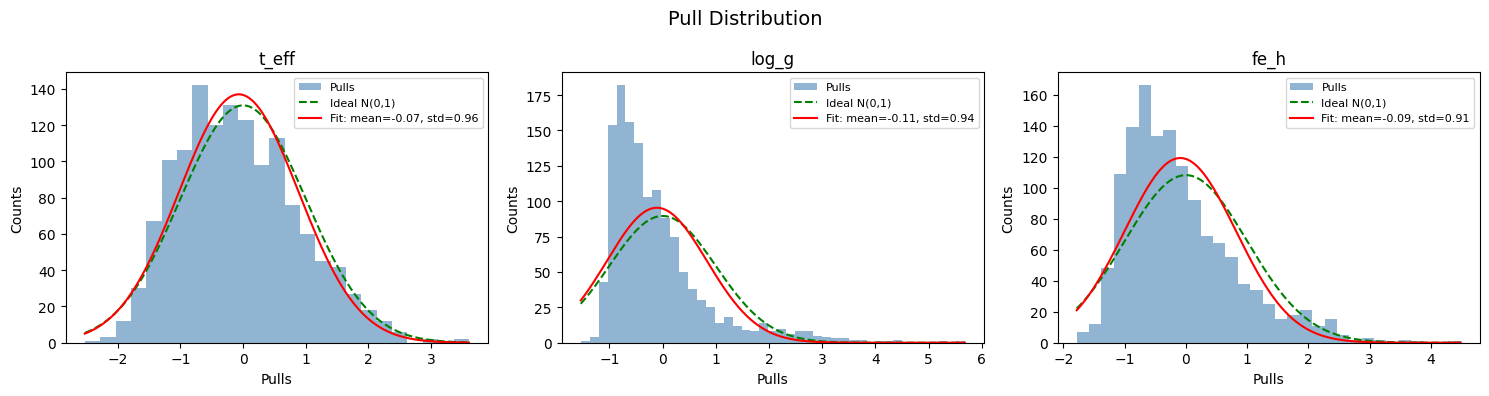

In [32]:
results = evaluate_uncertainty_quality(preds_flow, y_true, labelNames)

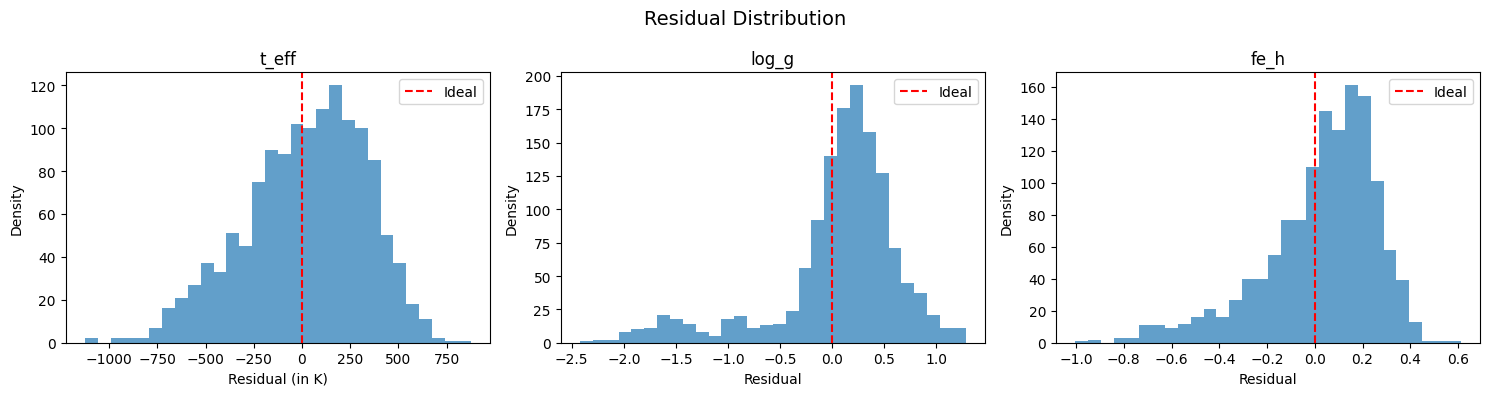

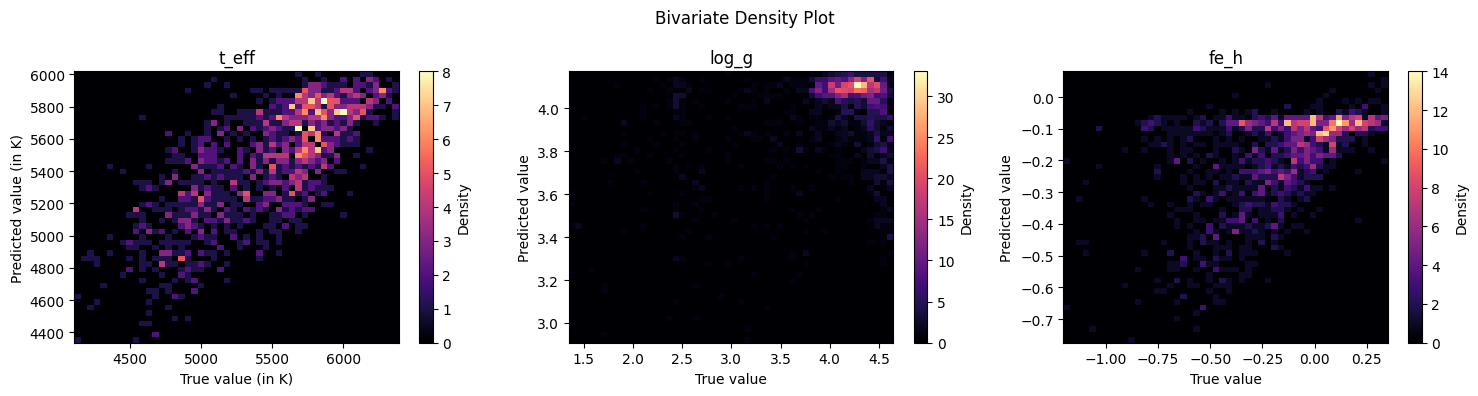

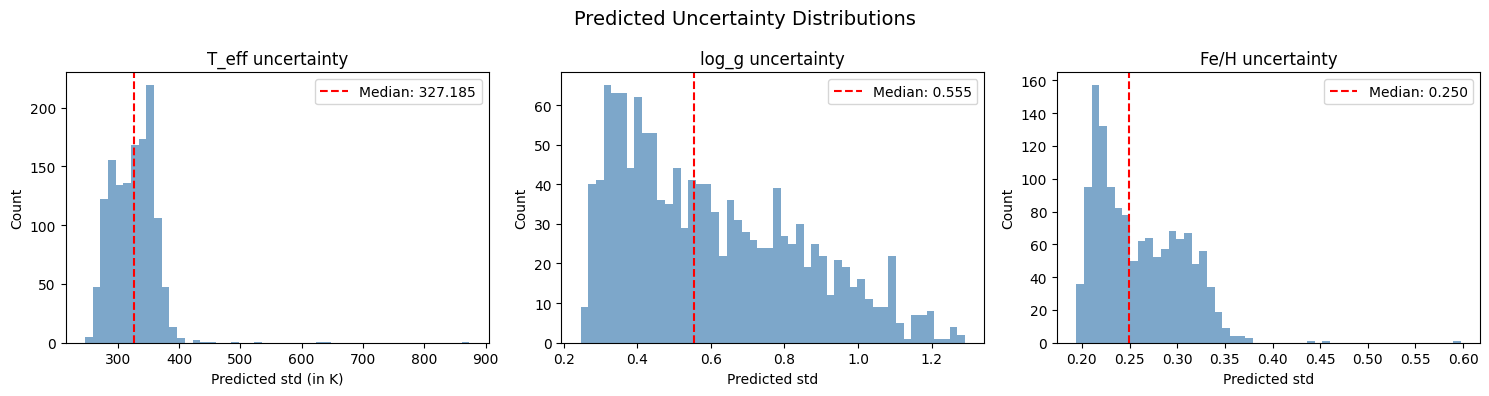

T_eff: median std = 327.1853, mean std = 325.6385, min = 246.5266, max = 873.4385
log_g: median std = 0.5549, mean std = 0.6002, min = 0.2455, max = 1.2912
Fe/H: median std = 0.2499, mean std = 0.2599, min = 0.1941, max = 0.5975


In [33]:
y_true_denorm = denormalize_labels(y_true, mean, std)
means_flow_denorm = denormalize_labels(preds_flow[:, :3], mean, std)
stds_flow_denorm = preds_flow[:, 3:] * std

plot_residuals(y_true_denorm, means_flow_denorm, labelNames, label_units=label_units)
plot_heatmap(y_true_denorm, means_flow_denorm, labelNames, label_units=label_units)

plot_uncertainty_distribution(stds_flow_denorm, label_units=label_units)

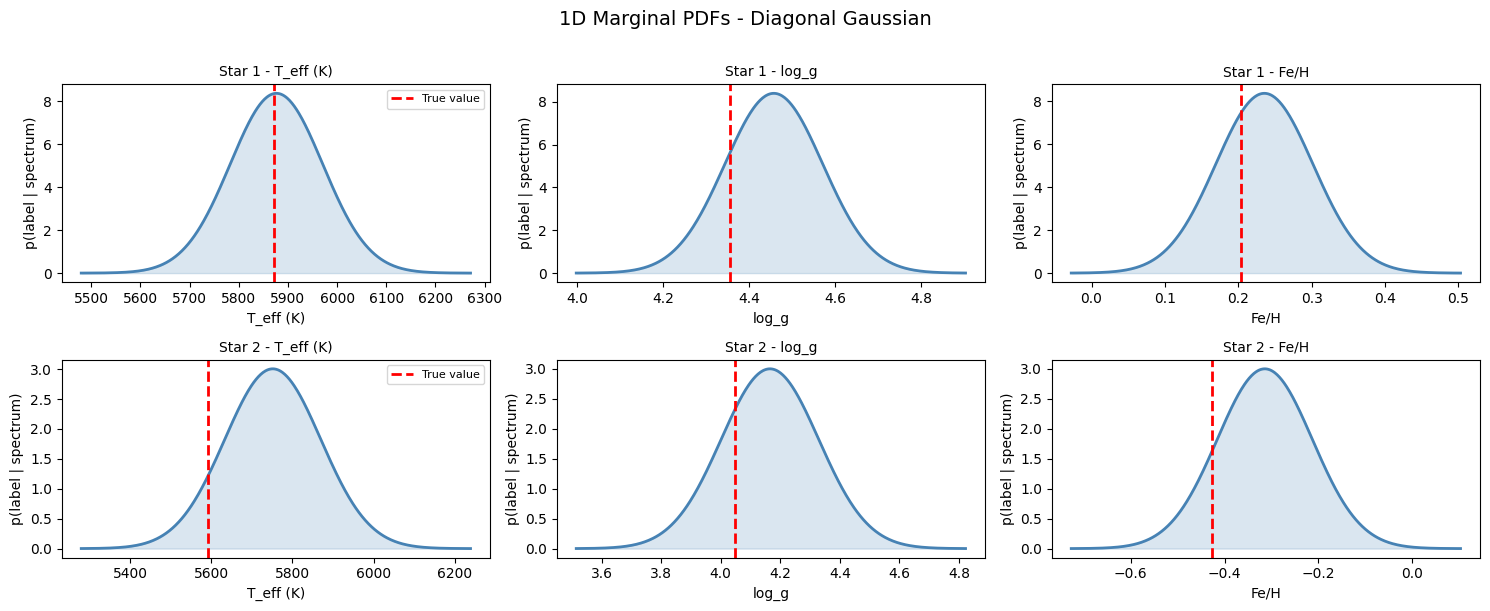

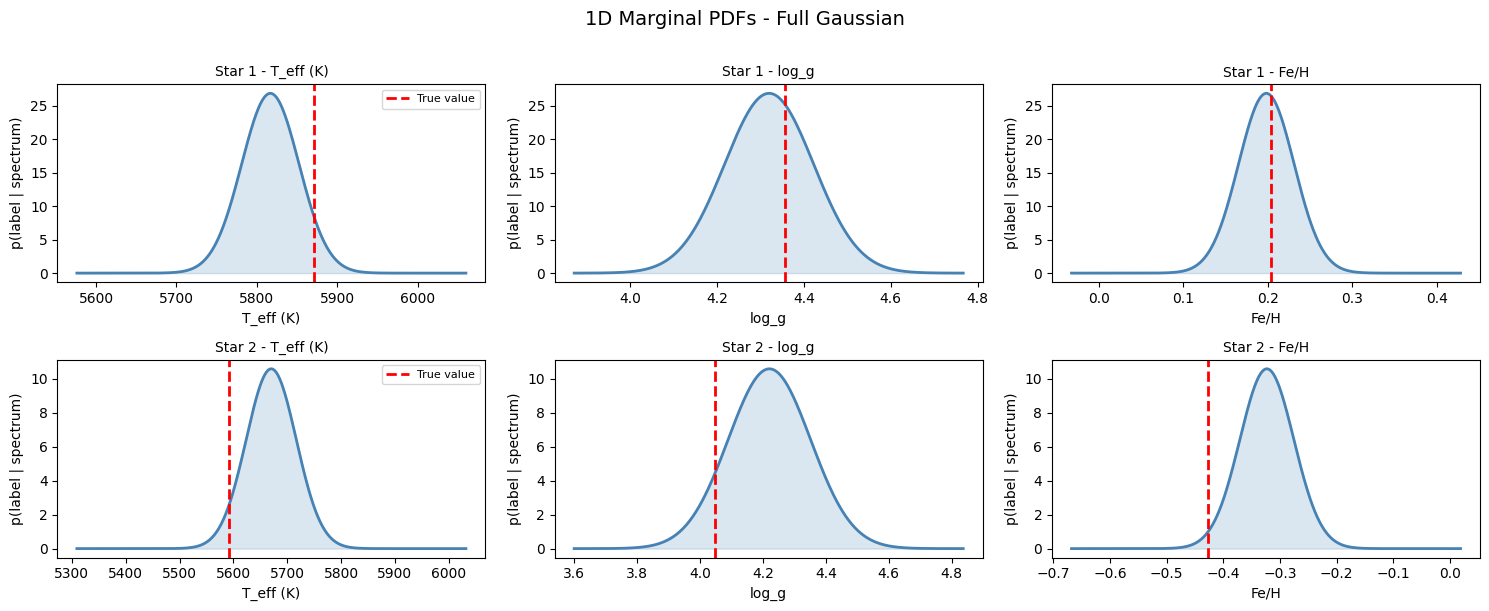

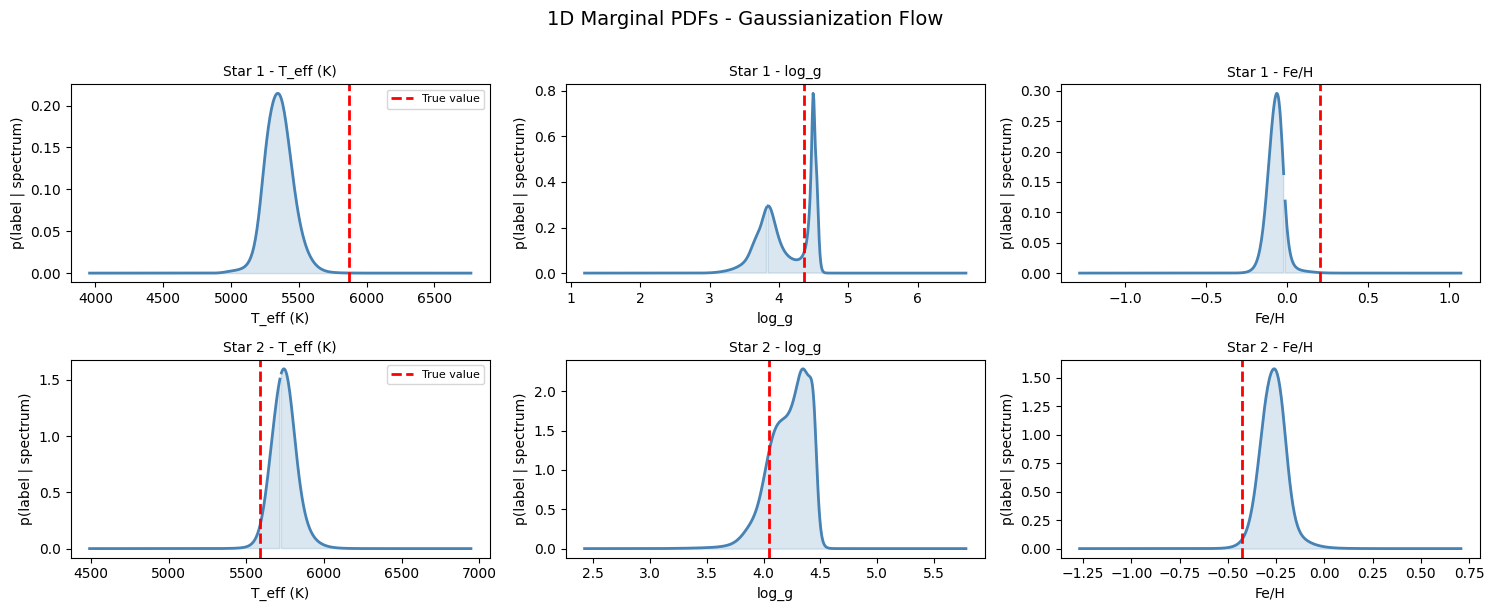

In [35]:
model_flow.eval()
model_full.eval()
model_diag.eval()

n_stars = 2
label_names = ["T_eff (K)", "log_g", "Fe/H"]
GRID_SIZE = 500

models = [
    (model_diag, preds_diag, "Diagonal Gaussian"),
    (model_full, preds_full, "Full Gaussian"),
    (model_flow, preds_flow, "Gaussianization Flow"),
]

test_spectra = torch.tensor(X_test[:n_stars], dtype=torch.float32).to(device)


for model, preds, model_name in models:

    with torch.no_grad():
        flow_params = model.encoder(test_spectra)

    fig, axes = plt.subplots(n_stars, 3, figsize=(15, 3 * n_stars))

    for i in range(n_stars):
        params_i       = flow_params[i].unsqueeze(0)
        pred_mean_norm = preds[i, :3]
        pred_std_norm  = preds[i, 3:]

        for j in range(3):
            ax = axes[i, j]

            lo = pred_mean_norm[j] - 4 * pred_std_norm[j]
            hi = pred_mean_norm[j] + 4 * pred_std_norm[j]
            grid_norm = torch.linspace(lo, hi, GRID_SIZE).to(device)

            label_grid = torch.tensor(pred_mean_norm, dtype=torch.float32) \
                             .unsqueeze(0).expand(GRID_SIZE, -1).clone().to(device)
            label_grid[:, j] = grid_norm

            with torch.no_grad():
                log_p, _, _ = model.pdf(
                    label_grid,
                    amortization_parameters=params_i.expand(GRID_SIZE, -1)
                )
            p = log_p.exp().cpu().numpy()

            grid_phys = grid_norm.cpu().numpy() * std[j] + mean[j]
            true_phys = y_test[i, j] * std[j] + mean[j]

            ax.plot(grid_phys, p, color="steelblue", linewidth=2)
            ax.axvline(true_phys, color="red", linewidth=2, linestyle="--", label="True value")
            ax.fill_between(grid_phys, p, alpha=0.2, color="steelblue")
            ax.set_title(f"Star {i+1} - {label_names[j]}", fontsize=10)
            ax.set_xlabel(label_names[j])
            ax.set_ylabel("p(label | spectrum)")
            if j == 0:
                ax.legend(fontsize=8)

    plt.suptitle(f"1D Marginal PDFs - {model_name}", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()